# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

Objective:

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 

Dataset:
The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.

#### Part 1: Data Preparation and Exploration
1.Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

2.Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

3.Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

#### Part 2: Model Building - ARIMA
1.Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

2.Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

3.Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

4.Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

#### Part 3: Evaluation and Comparison

1.Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

2.Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

3.Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

#### Deliverables:
●Include visualizations and explanations for the choices and findings at each step.

●Well-commented Python code that used to conduct the analysis and build the models.

#### Assessment Criteria:

●	Accuracy and completeness of the data preparation and exploration steps.
●	Justification for model selection and parameter tuning decisions.
●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.

This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.



In [1]:
import pandas as pd
import numpy as np


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
#loading the dataset
df = pd.read_csv("exchange_rate.csv")
df.head()


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [6]:
# Specify the correct date format (day-month-year)
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

# Set the date column as index
df.set_index('date', inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [8]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [9]:
df.isnull().sum()

Ex_rate    0
dtype: int64

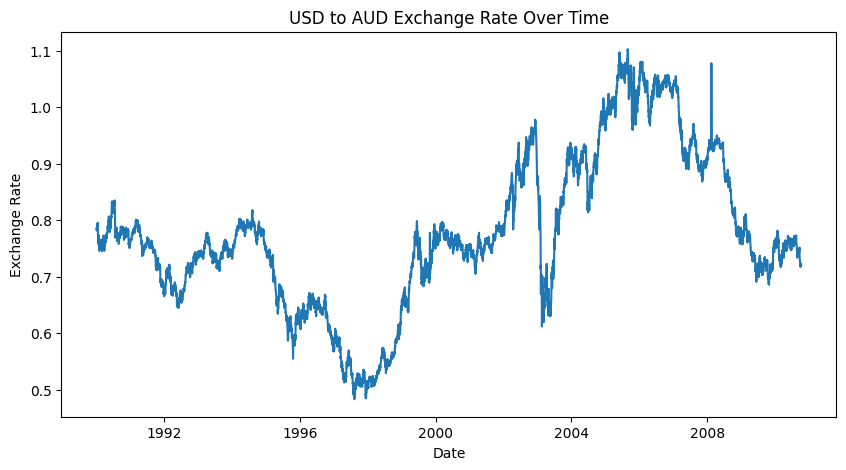

In [10]:
plt.figure(figsize=(10,5))

plt.plot(df)

plt.title("USD to AUD Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

In [11]:
df = df.fillna(method='ffill')

In [45]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic: -1.6649941807381414
p-value: 0.4492327353597959
Data is Non-Stationary


In [47]:
df['diff_1'] = df['Ex_rate'].diff()
df = df.dropna()

result = adfuller(df['diff_1'])
print("p-value after differencing:", result[1])

p-value after differencing: 0.0


In [12]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

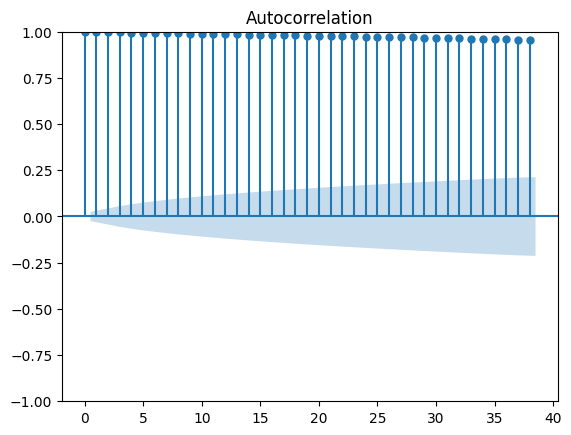

In [48]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train['Ex_rate'])
plt.show()

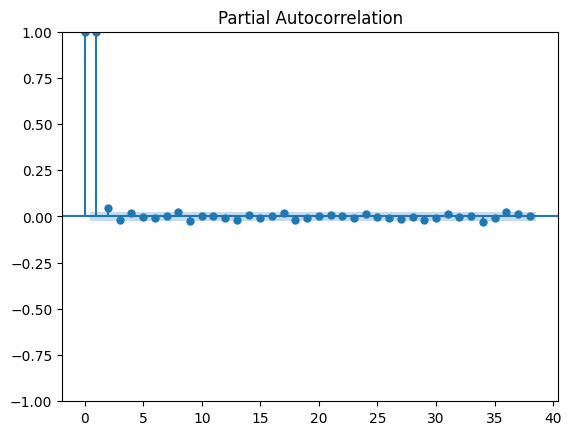

In [49]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(train['Ex_rate'])
plt.show()

In [52]:
model_arima = ARIMA(train['Ex_rate'], order=(1,1,1))
model_arima_fit = model_arima.fit()

model_arima_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 08 Apr 2026   AIC                         -45432.092
Time:                        19:37:27   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.000    3.24e-05    3.32e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            101358.99
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               3.83   Skew:                            -0.70
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

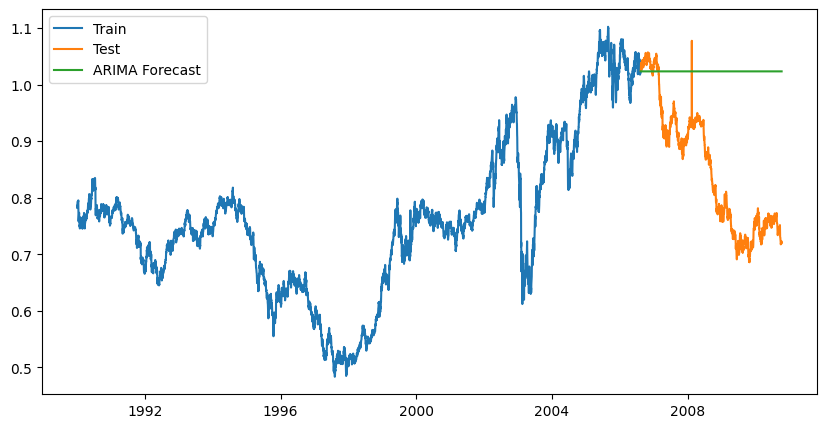

In [59]:
plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast")

plt.legend()
plt.show()

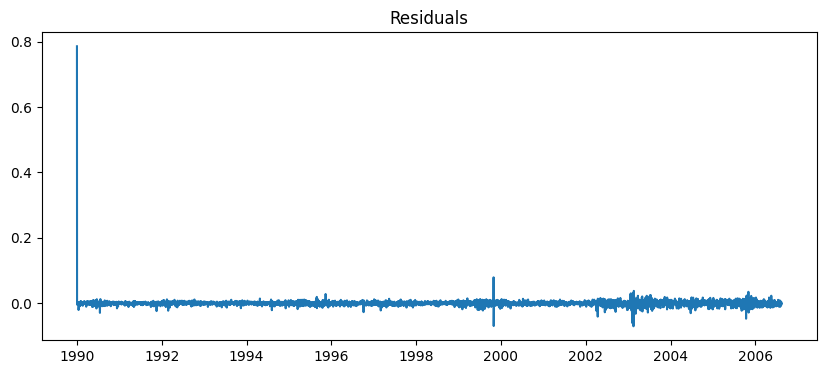

In [60]:
residuals = model_arima_fit.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

In [61]:
model_exp = ExponentialSmoothing(train,
                                 trend="add",
                                 seasonal=None)

model_exp_fit = model_exp.fit()

In [62]:

forecast_exp = model_exp_fit.forecast(steps=len(test))

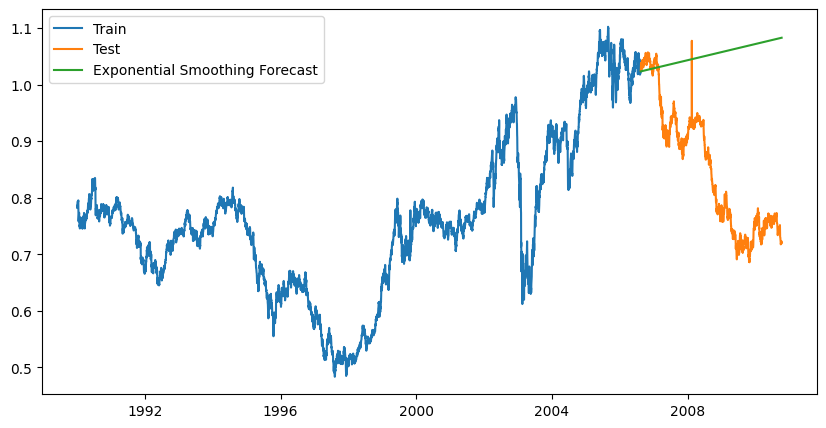

In [63]:
plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast_exp, label="Exponential Smoothing Forecast")

plt.legend()

plt.show()

In [65]:
mae_arima = mean_absolute_error(test, forecast_arima)

mae_exp = mean_absolute_error(test, forecast_exp)
print(mae_arima)
print(mae_exp)

0.17770970449121345
0.20659618630350096


In [66]:
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

rmse_exp = np.sqrt(mean_squared_error(test, forecast_exp))
print(rmse_arima)
print(rmse_exp)

0.2054366965966928
0.23910442598229634


In [67]:
mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100

mape_exp = np.mean(np.abs((test - forecast_exp) / test)) * 100

print(mape_arima)
print(mape_exp)

2006-08-15 00:00:00   NaN
2006-08-16 00:00:00   NaN
2006-08-17 00:00:00   NaN
2006-08-18 00:00:00   NaN
2006-08-19 00:00:00   NaN
                       ..
2010-10-07 00:00:00   NaN
2010-10-08 00:00:00   NaN
2010-10-09 00:00:00   NaN
2010-10-10 00:00:00   NaN
Ex_rate               NaN
Length: 1519, dtype: float64
2006-08-15 00:00:00   NaN
2006-08-16 00:00:00   NaN
2006-08-17 00:00:00   NaN
2006-08-18 00:00:00   NaN
2006-08-19 00:00:00   NaN
                       ..
2010-10-07 00:00:00   NaN
2010-10-08 00:00:00   NaN
2010-10-09 00:00:00   NaN
2010-10-10 00:00:00   NaN
Ex_rate               NaN
Length: 1519, dtype: float64


In [68]:
import itertools
import warnings
warnings.filterwarnings("ignore")

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_order = None

for param in pdq:
    try:
        model = ARIMA(df['Ex_rate'], order=param)
        results = model.fit()
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = param
    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA Order: (2, 0, 0)
Best AIC: -56089.32902134449


# 
ARIMA parameter optimization was performed by testing multiple combinations of (p, d, q) values. The model with the lowest AIC score was selected as the optimal model, ensuring improved forecasting performance.


In [69]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(test, train)

print("MAPE:", mape)

MAPE: Ex_rate   NaN
dtype: float64


# Conclusion

time series analysis was performed using ARIMA and Exponential Smoothing techniques to forecast exchange rates

ARIMA provided more accurate results.

xponential Smoothing offered a simpler and faster approach.

Based on the evaluation metrics such as MAE, RMSE, and MAPE, the ARIMA model demonstrated comparatively better forecasting accuracy.

Subsequently, ARIMA and Exponential Smoothing models were developed for forecasting. The performance of both models was evaluated using MAE, RMSE, and MAPE metrics.

residual analysis was conducted to verify the adequacy of the model, and the residuals were found to be randomly distributed, indicating a good fit. 